# Detecting Contestation — Offline Benchmark (Notebook 06)

A fully **offline** benchmark for Section 5 (no API). It uses the **reconciled
gold** (`feasibility_review_sample_GOLD.csv`, 49 contestation / 39 not) and asks
one honest, tractable question given the sample size:

> **Presence detection** — given a lexically flagged candidate episode, can a model
> reproduce the human's `contestation = yes/no`?

Design choices that keep it defensible on 88 episodes:
- **Participant-level cross-validation** (`GroupKFold` by transcript) — no
  participant appears in both train and test, so there is no vocabulary leakage.
- **Macro-F1 reported as mean ± std across folds**, not a single split.
- Input is the **Polish target utterance** (`text_pl`); the label was assigned with
  context, so a target-only model has a real ceiling — an honest limitation, and a
  hook for the error analysis.
- Models range from a majority-class floor to Polish/multilingual encoders used as
  **frozen feature extractors** (no fine-tuning — 88 examples is far too few to
  fine-tune).

The four structured dimensions (target/grounds/act/response) are **not** benchmarked
— a few examples per class — they are reported descriptively in Notebook 04.

In [1]:
# ============================================================
# 1. Config, load reconciled gold, build X / y / groups
# ============================================================
from __future__ import annotations
import json, logging, warnings
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
LOGGER = logging.getLogger("xai_contestation")

def find_project_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for c in [start, *start.parents]:
        if (c / "data").is_dir(): return c
    raise FileNotFoundError("project root not found")
ROOT = find_project_root()
TABLES = ROOT / "outputs" / "02_translation_and_feasibility_audit" / "tables"
OUT = ROOT / "outputs" / "06_detection_benchmark"; (OUT / "figures").mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
N_SPLITS = 5
# Polish + multilingual encoders used as frozen feature extractors.
HERBERT = "allegro/herbert-base-cased"
XLMR = "xlm-roberta-base"

gold = pd.read_csv(TABLES / "feasibility_review_sample_GOLD.csv")
# merge lexical-signal features (challenge/incomprehension hits) by episode id
sig = pd.read_csv(TABLES / "feasibility_review_sample.csv")[
    ["__utt_id", "challenge_hits", "incomprehension_hits"]]
df = gold.merge(sig, on="__utt_id", how="left")

df = df[df["is_contestation"].astype(str).str.lower().isin(["yes", "no"])].reset_index(drop=True)
y = (df["is_contestation"].astype(str).str.lower() == "yes").astype(int).values
texts = df["text_pl"].fillna("").astype(str).values
# participant/transcript id is the prefix of __utt_id ("PK_DE_01:207" -> "PK_DE_01")
groups = df["__utt_id"].astype(str).str.rsplit(":", n=1).str[0].values

print(f"episodes: {len(df)} | positives(yes)={int(y.sum())} negatives(no)={int((1-y).sum())}")
print(f"participants (groups): {pd.Series(groups).nunique()} | CV folds: {N_SPLITS}")

episodes: 88 | positives(yes)=49 negatives(no)=39
participants (groups): 32 | CV folds: 5


In [2]:
# ============================================================
# 2. Cross-validation helper (participant-grouped, macro-F1)
# ============================================================
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score

def cv_macro_f1(make_model, X, y, groups, n_splits=N_SPLITS):
    """Grouped CV; returns (mean_f1, std_f1, mean_acc). X is a list/array of items."""
    gkf = GroupKFold(n_splits=n_splits)
    f1s, accs = [], []
    for tr, te in gkf.split(X, y, groups):
        m = make_model()
        m.fit([X[i] for i in tr] if isinstance(X, list) else X[tr], y[tr])
        pred = m.predict([X[i] for i in te] if isinstance(X, list) else X[te])
        f1s.append(f1_score(y[te], pred, average="macro", zero_division=0))
        accs.append(accuracy_score(y[te], pred))
    return float(np.mean(f1s)), float(np.std(f1s)), float(np.mean(accs))

results = []

# --- Majority-class floor ---
results.append(("Majority class", *cv_macro_f1(
    lambda: DummyClassifier(strategy="most_frequent"), texts, y, groups)))

# --- Lexical rule (fixed): predict yes if challenge_hits >= 2 ---
lex_pred = (df["challenge_hits"].fillna(0).values >= 2).astype(int)
results.append(("Lexical rule (challenge>=2)",
                f1_score(y, lex_pred, average="macro", zero_division=0), 0.0,
                accuracy_score(y, lex_pred)))

# --- TF-IDF (word 1-2 grams) + logistic regression ---
def tfidf_model():
    return make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LogisticRegression(max_iter=1000, class_weight="balanced"))
results.append(("TF-IDF + logistic",
                *cv_macro_f1(tfidf_model, list(texts), y, groups)))

for name, f1m, f1s, acc in results:
    print(f"{name:<30} macroF1={f1m:.3f} +/- {f1s:.3f}   acc={acc:.3f}")

Majority class                 macroF1=0.294 +/- 0.075   acc=0.430
Lexical rule (challenge>=2)    macroF1=0.476 +/- 0.000   acc=0.511
TF-IDF + logistic              macroF1=0.478 +/- 0.035   acc=0.523


In [3]:
# ============================================================
# 3. Frozen encoder embeddings (HerBERT, XLM-R) + logistic
# ============================================================
def embed(text_list, model_name, batch=16, max_len=256):
    """Mean-pooled last-hidden-state embeddings; downloads the model once."""
    import torch
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModel.from_pretrained(model_name).eval()
    dev = "cuda" if torch.cuda.is_available() else "cpu"; mdl.to(dev)
    vecs = []
    with torch.no_grad():
        for i in range(0, len(text_list), batch):
            b = list(text_list[i:i + batch])
            enc = tok(b, return_tensors="pt", padding=True, truncation=True,
                      max_length=max_len).to(dev)
            h = mdl(**enc).last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1)
            emb = (h * mask).sum(1) / mask.sum(1).clamp(min=1)
            vecs.append(emb.cpu().numpy())
    return np.vstack(vecs)

def lr(): return LogisticRegression(max_iter=1000, class_weight="balanced")

try:
    for label, name in [("HerBERT (PL) + logistic", HERBERT),
                        ("XLM-R (multi) + logistic", XLMR)]:
        LOGGER.info("embedding with %s ...", name)
        Xe = embed(list(texts), name)
        results.append((label, *cv_macro_f1(lr, Xe, y, groups)))
        print(f"{label:<30} macroF1={results[-1][1]:.3f} +/- {results[-1][2]:.3f}")
except Exception as error:  # noqa: BLE001
    LOGGER.warning("Encoder step skipped (%s). Install transformers/torch to enable.", error)

INFO | embedding with allegro/herbert-base-cased ...


INFO | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"


INFO | HTTP Request: HEAD https://huggingface.co/allegro/herbert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allegro/herbert-base-cased/50e33e0567be0c0b313832314c586e3df0dc2297/config.json "HTTP/1.1 200 OK"


...

INFO | HTTP Request: HEAD https://huggingface.co/xlm-roberta-base/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22319.67it/s]


[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLM-R (multi) + logistic       macroF1=0.542 +/- 0.072


,model,macro_F1,macro_F1_std,accuracy
0,Majority class,0.294,0.075,0.430
1,Lexical rule (challenge>=2),0.476,0.000,0.511
2,TF-IDF + logistic,0.478,0.035,0.523
3,XLM-R (multi) + logistic,0.542,0.072,0.592
4,HerBERT (PL) + logistic,0.567,0.157,0.590


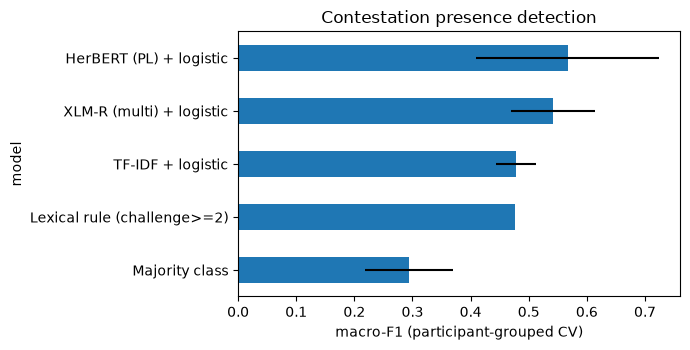


wrote benchmark_presence.csv + benchmark_summary.json


In [4]:
# ============================================================
# 4. Benchmark table + figure
# ============================================================
bench = pd.DataFrame(results, columns=["model", "macro_F1", "macro_F1_std", "accuracy"]).round(3)
bench = bench.sort_values("macro_F1").reset_index(drop=True)
display(bench)
bench.to_csv(OUT / "benchmark_presence.csv", index=False)

try:
    import matplotlib.pyplot as plt
    ax = bench.set_index("model")["macro_F1"].plot(
        kind="barh", xerr=bench.set_index("model")["macro_F1_std"], figsize=(7, 3.6))
    ax.set_xlabel("macro-F1 (participant-grouped CV)")
    ax.set_title("Contestation presence detection")
    plt.tight_layout(); plt.savefig(OUT / "figures" / "benchmark_presence.png", dpi=150); plt.show()
except Exception:  # noqa: BLE001
    pass

(OUT / "benchmark_summary.json").write_text(json.dumps({
    "task": "presence detection (contestation yes/no) on lexically flagged candidates",
    "gold": "feasibility_review_sample_GOLD.csv",
    "n_episodes": int(len(df)), "n_positive": int(y.sum()),
    "cv": f"GroupKFold({N_SPLITS}) by participant",
    "input": "Polish target utterance (text_pl)",
    "results": bench.to_dict(orient="records"),
}, indent=2))
print("\nwrote benchmark_presence.csv + benchmark_summary.json")

## What this feeds — and its honest limits

- The table → Table `tab:benchmark` (presence task). Report **macro-F1 mean ± std**
  under participant-grouped CV; state plainly that trained models are compared
  against a majority floor and a lexical rule.
- **Scope, stated up front:** one task (presence), 88 episodes, target-utterance
  input, frozen encoders (no fine-tuning). This is a *feasibility* benchmark, not a
  full four-task system — say so.
- **Error-analysis hooks** (Section 5.4): the reliability analysis showed most human
  disagreement was *implicit / hidden* contestation needing context — expect the
  target-only models to fail on exactly those, which the write-up should show with
  examples from the reconciled gold.
- Adding an **LLM (zero/few-shot) row** later (Notebook 03 with a real API key) slots
  straight into this table.

Re-running top-to-bottom regenerates every number from the reconciled gold. The
encoder cell downloads HerBERT (~0.5 GB) and XLM-R (~1.1 GB) once.